O algoritmo K-means pode ser adaptado como um detector de anomalias ao explorar a distância entre pontos de dados e os centróides dos clusters.

Anomalias (ou outliers) são observações que se desviam significativamente da maioria dos dados e, portanto, tendem a estar mais distantes dos centróides.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Vamos supor um conjunto de dados 2D com dois clusters normais e alguns pontos anômalos.

### Geração e padronização do dados

In [ ]:
# Dados sintéticos
np.random.seed(42)
normal_data = np.concatenate([
    np.random.normal(loc=[1, 1], scale=0.5, size=(100, 2)),
    np.random.normal(loc=[5, 5], scale=0.5, size=(100, 2))
])
anomalies = np.array([[10, 10], [-3, 5], [3, 10], [7, -2]])
X = np.vstack([normal_data, anomalies])

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

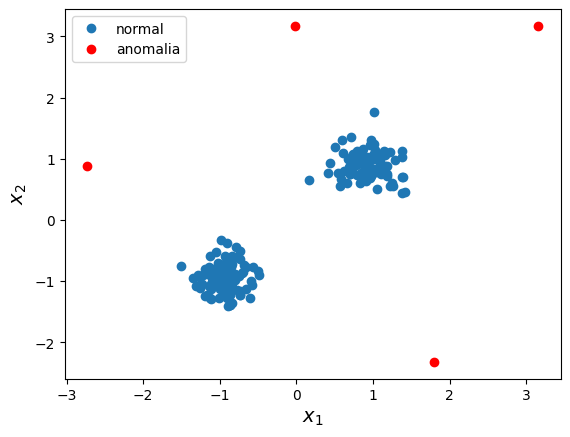

In [ ]:
plt.plot(X_scaled[:len(X_scaled)-4,0], X_scaled[:len(X_scaled)-4,1], 'o', label='normal')
plt.plot(X_scaled[len(X_scaled)-4:,0], X_scaled[len(X_scaled)-4:,1], 'ro', label='anomalia')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.legend()
plt.show()

### Aplicando o K-means

In [ ]:
num_centers = 2

kmeans = KMeans(n_clusters=num_centers, random_state=42)

kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

### Apresentando os centroides

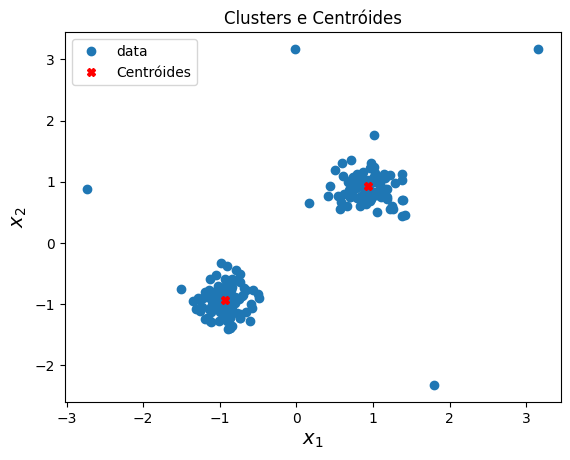

In [ ]:
plt.plot(X_scaled[:, 0], X_scaled[:, 1], 'o', label='data')
plt.plot(centroids[:, 0], centroids[:, 1], 'rX', label='Centróides')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title("Clusters e Centróides")
plt.legend()
plt.show()

### Definindo um limiar para identificar anomalias

Vamos usar o percentil alto para definir o limite.

OBS.: O Xº percentil é uma medida estatística que indica o valor abaixo do qual estão X% das observações em um conjunto de dados ordenados. Em outras palavras, X% dos dados são menores ou iguais a esse valor, e apenas (100-X)% são maiores. Ele é amplamente utilizado para identificar limites em distribuições de dados, como em casos de detecção de anomalias.

In [ ]:
percentile_treshold = 97

### Cálculo das distâncias dos pontos aos centróides

In [ ]:
# distâncias até cada um dos centroides
distances = kmeans.transform(X_scaled)

# centroide com menor distância
y_kmeans = kmeans.predict(X_scaled)

center_distances = {key: [] for key in range(num_centers)}
indexes = {key: [] for key in range(num_centers)}
for i in range(len(y_kmeans)):
  min_distance = distances[i, y_kmeans[i]]
  center_distances[y_kmeans[i]].append(min_distance)
  indexes[y_kmeans[i]].append(i)

threshold = {key : np.percentile(center_distances[key], percentile_treshold) for key in center_distances.keys()}

### Encontrando o limiar para o primeiro cluster

In [ ]:
anomaly_indices1 = np.where(center_distances[0] > threshold[0])[0]
anomalies_detected1 = X_scaled[np.array(indexes[0])[anomaly_indices1]]

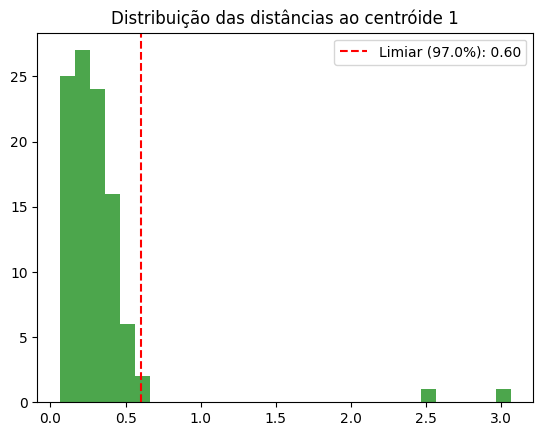

In [ ]:
plt.figure()
plt.hist(center_distances[0], bins=30, color='green', alpha=0.7)
plt.axvline(threshold[0], color='red', linestyle='--', label=f'Limiar ({percentile_treshold:.1f}%): {threshold[0]:.2f}')
plt.title("Distribuição das distâncias ao centróide 1")
plt.legend()
plt.show()

### Encontrando o limiar para o segundo cluster

In [ ]:
anomaly_indices2 = np.where(center_distances[1] > threshold[1])[0]
anomalies_detected2 = X_scaled[np.array(indexes[1])[anomaly_indices2]]

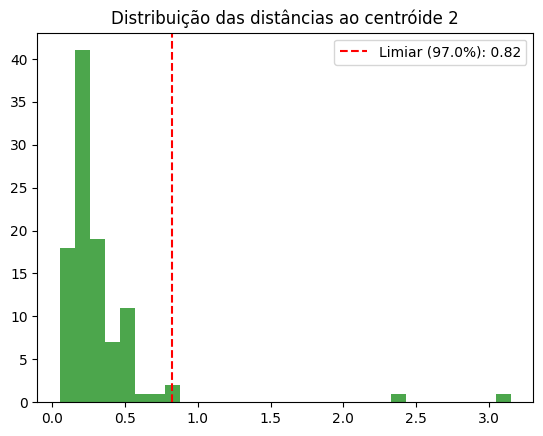

In [ ]:
plt.figure()
plt.hist(center_distances[1], bins=30, color='green', alpha=0.7)
plt.axvline(threshold[1], color='red', linestyle='--', label=f'Limiar ({percentile_treshold:.1f}%): {threshold[1]:.2f}')
plt.title("Distribuição das distâncias ao centróide 2")
plt.legend()
plt.show()

### Anomalias Detectadas

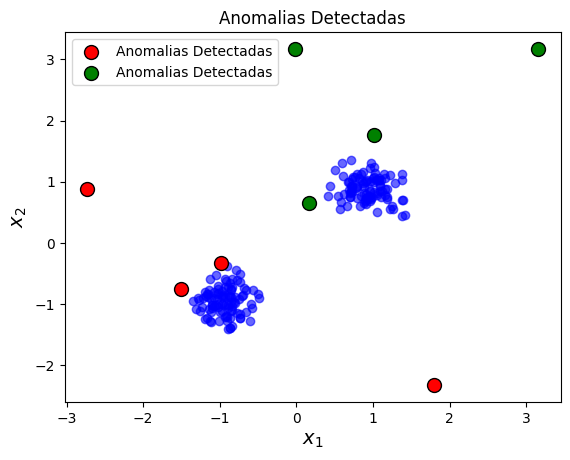

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='blue', alpha=0.6)
plt.scatter(anomalies_detected1[:, 0], anomalies_detected1[:, 1], c='red', s=100, edgecolors='black', label='Anomalias Detectadas')
plt.scatter(anomalies_detected2[:, 0], anomalies_detected2[:, 1], c='green', s=100, edgecolors='black', label='Anomalias Detectadas')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title("Anomalias Detectadas")
plt.legend()
plt.show()

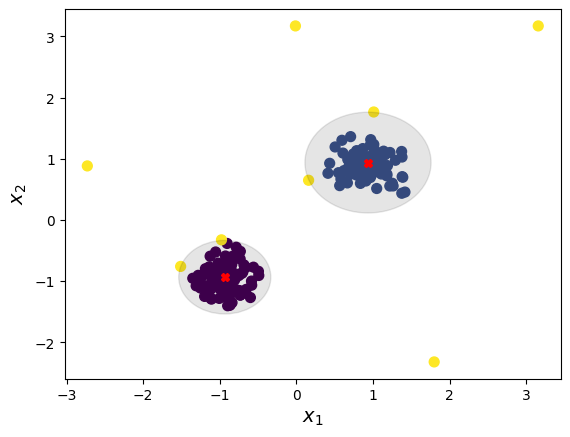

In [ ]:
fig, ax = plt.subplots()

colors = []
for i in range(len(X_scaled)):
  min_distance = distances[i][y_kmeans[i]]
  if (min_distance > threshold[y_kmeans[i]]):
    colors.append(4)
  else:
    colors.append(y_kmeans[i])

ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, s=50, cmap='viridis')
plt.plot(centroids[:, 0], centroids[:, 1], 'rX', label='Centróides')

for i in range(len(centroids)):
  circle = plt.Circle((centroids[i][0], centroids[i][1]),threshold[i], color='black', alpha=0.1)
  ax.add_artist(circle)

plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.show()

O K-means não foi pensado em detecção de anomalias. Assim, existem outros algortimos mais adequados.

+ Isolation Forest
+ One-Class SVM
+ Local Outlier Factor
+ etc.